In [159]:
# from google.colab import files
# uploaded = files.upload()

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
train=pd.read_csv("/content/drive/MyDrive/Rossmann_LSTM_Project/data/rossmann-store-sales/train.csv")
test=pd.read_csv("/content/drive/MyDrive/Rossmann_LSTM_Project/data/rossmann-store-sales/test.csv")
store=pd.read_csv("/content/drive/MyDrive/Rossmann_LSTM_Project/data/rossmann-store-sales/store.csv")


/tmp/ipykernel_4120/1090064581.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/rossmann-store-sales/train.csv")


In [162]:
store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


# GOAL
: We need to forecast 6-week sales per store to optimise

* inventory planning
* staff scheduling
* promotions
* supply chain management




# THE BUISNESS PROBLEM:


---


Rossmann operates 1,115 drug stores. Store managers currently place
orders for inventory manually, based on intuition and experience.
This leads to two expensive problems:
* overstocking (products expire or take up shelf space) and
* stockouts (lost sales, unhappy customers).


---



 The question is: Can we predict the next 6 weeks of daily sales per store with enough accuracy that we can automate or assist inventory decisions?

# FORECASTING OBJECTIVE

 Predict daily Sales for each store for Aug–Sep 2015 (the test period). This is a supervised, univariate, multi-step time series regression problem.

| Column                      | Meaning                                        | Type                               |
| --------------------------- | ---------------------------------------------- | ---------------------------------- |
| `Store`                     | Unique ID for each store                       | Numerical (Identifier/Categorical) |
| `StoreType`                 | Category/type of store                         | Categorical                        |
| `Assortment`                | Variety level of products offered              | Categorical                        |
| `CompetitionDistance`       | Distance to nearest competitor store           | Numerical (Continuous)             |
| `CompetitionOpenSinceMonth` | Month when competitor opened                   | Numerical (Discrete/Time-based)    |
| `CompetitionOpenSinceYear`  | Year when competitor opened                    | Numerical (Discrete/Time-based)    |
| `Promo2`                    | Whether store runs continuous promotions (0/1) | Categorical (Binary)               |
| `Promo2SinceWeek`           | Week when Promo2 started                       | Numerical (Discrete/Time-based)    |
| `Promo2SinceYear`           | Year when Promo2 started                       | Numerical (Discrete/Time-based)    |
| `PromoInterval`             | Months when recurring promotions occur         | Categorical                        |


In [163]:
train.isnull().sum()


,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [164]:
store.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


In [165]:
store["CompetitionDistance"] = store[ "CompetitionDistance"].fillna(store["CompetitionDistance"].median())
store["CompetitionOpenSinceMonth"] = store[ "CompetitionOpenSinceMonth"].fillna(0)
store["CompetitionOpenSinceYear"] = store[ "CompetitionOpenSinceYear"].fillna(0)
store["Promo2SinceWeek"] = store[ "Promo2SinceWeek"].fillna(0)
store["Promo2SinceYear"] = store[ "Promo2SinceYear"].fillna(0)
store["PromoInterval"] = store[ "PromoInterval"].fillna("NoPromo")

In [166]:
store.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,0
CompetitionOpenSinceMonth,0
CompetitionOpenSinceYear,0
Promo2,0
Promo2SinceWeek,0
Promo2SinceYear,0
PromoInterval,0


In [167]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [168]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Std_7
30,31,5,2015-07-31,7248,645,1,1,0,1,d,...,0.0,NoPromo,2015,7,31,31,14190.0,5263.0,9135.285714,3411.206517
31,32,5,2015-07-31,6395,635,1,1,0,0,a,...,2009.0,"Feb,May,Aug,Nov",2015,7,31,31,14180.0,6064.0,8023.142857,2683.901726
32,33,5,2015-07-31,10789,915,1,1,0,1,a,...,0.0,NoPromo,2015,7,31,31,7818.0,8314.0,8447.571429,2874.220930
33,34,5,2015-07-31,11144,1162,1,1,0,1,c,...,0.0,NoPromo,2015,7,31,31,13213.0,13995.0,8152.000000,2363.498678
34,35,5,2015-07-31,12412,777,1,1,0,1,d,...,2012.0,"Jan,Apr,Jul,Oct",2015,7,31,31,7301.0,4822.0,8882.142857,2805.007274


In [169]:
df = train.merge(store, on="Store", how="left")

In [170]:
# Removing closed stores as  the store was NOT operating-
# customers did not reject products
# demand did not suddenly disappear
# business was simply closed


In [171]:
df = df[df["Open"] == 1]

In [172]:
df["Date"] = pd.to_datetime(df["Date"])

In [173]:
df["Date"] = pd.to_datetime(df["Date"])

In [174]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [175]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,NoPromo
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NoPromo


In [176]:
df["Sales"].describe()

,Sales
count,844392.000000
mean,6955.514291
std,3104.214680
min,0.000000
25%,4859.000000
50%,6369.000000
75%,8360.000000
max,41551.000000


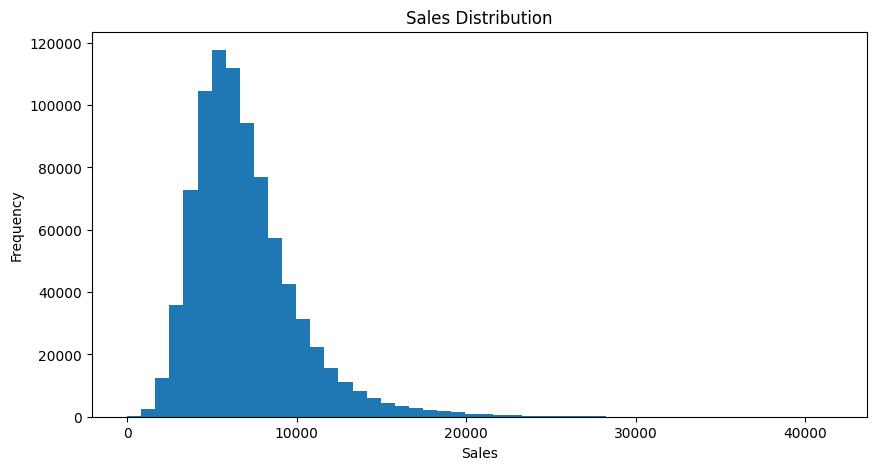

In [177]:
plt.figure(figsize=(10,5))

plt.hist(df["Sales"], bins=50)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

TECHNICAL OBSERVATION : Sales distribution is moderately right-skewed with several high-value outliers.

BUSINESS INTERPRETATION : Most stores operate within a stable sales range, while promotions and seasonal demand create occasional large sales spikes.

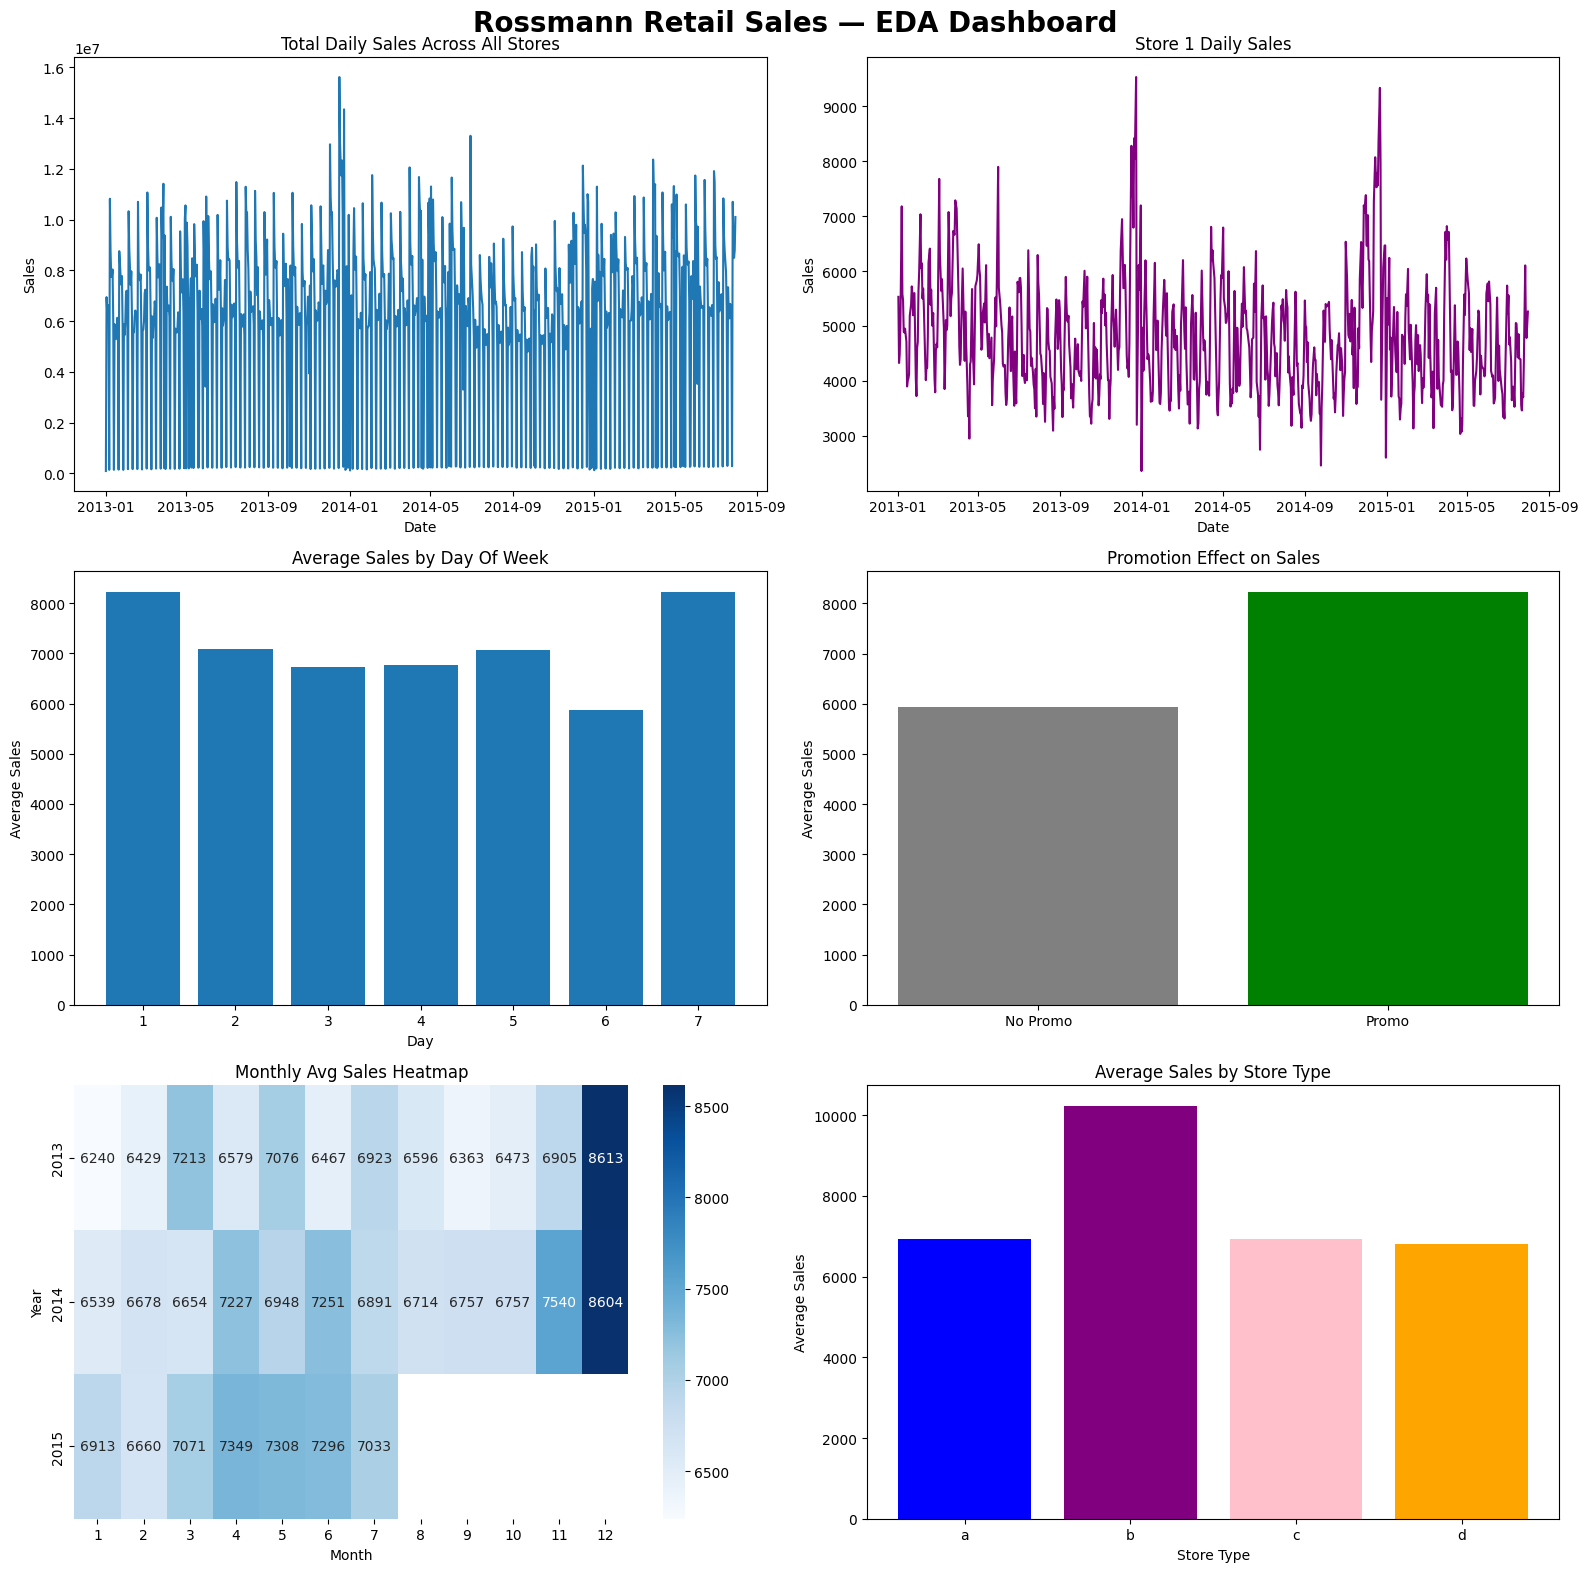

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

# CREATE DASHBOARD
fig, axes = plt.subplots(3, 2, figsize=(16,16))

fig.suptitle(
    "Rossmann Retail Sales — EDA Dashboard",
    fontsize=20,
    fontweight="bold"
)

# -----------------------------
# 1. Total Daily Sales
# -----------------------------
daily_sales = df.groupby("Date")["Sales"].sum()

axes[0,0].plot(daily_sales)

axes[0,0].set_title("Total Daily Sales Across All Stores")
axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Sales")

# -----------------------------
# 2. Store 1 Sales
# -----------------------------
store1 = df[df["Store"] == 1]

axes[0,1].plot(
    store1["Date"],
    store1["Sales"],
    color="purple"
)

axes[0,1].set_title("Store 1 Daily Sales")
axes[0,1].set_xlabel("Date")
axes[0,1].set_ylabel("Sales")

# -----------------------------
# 3. Day Of Week
# -----------------------------
dow_sales = df.groupby("DayOfWeek")["Sales"].mean()

axes[1,0].bar(
    dow_sales.index,
    dow_sales.values
)

axes[1,0].set_title("Average Sales by Day Of Week")
axes[1,0].set_xlabel("Day")
axes[1,0].set_ylabel("Average Sales")

# -----------------------------
# 4. Promo Effect
# -----------------------------
promo_sales = df.groupby("Promo")["Sales"].mean()

axes[1,1].bar(
    ["No Promo", "Promo"],
    promo_sales.values,
    color=["gray", "green"]
)

axes[1,1].set_title("Promotion Effect on Sales")
axes[1,1].set_ylabel("Average Sales")

# -----------------------------
# 5. Heatmap
# -----------------------------
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

monthly_pivot = df.pivot_table(
    values="Sales",
    index="Year",
    columns="Month",
    aggfunc="mean"
)

sns.heatmap(
    monthly_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    ax=axes[2,0]
)

axes[2,0].set_title("Monthly Avg Sales Heatmap")

# -----------------------------
# 6. Store Type
# -----------------------------
storetype_sales = df.groupby("StoreType")["Sales"].mean()

axes[2,1].bar(
    storetype_sales.index,
    storetype_sales.values,
    color=["blue","purple","pink","orange"]
)

axes[2,1].set_title("Average Sales by Store Type")
axes[2,1].set_xlabel("Store Type")
axes[2,1].set_ylabel("Average Sales")

# FINAL
plt.tight_layout()

plt.show()


#Feature Engineering + Preprocessing

CALENDER FEATURES

In [179]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week

LAG FEATURES


---


Retail sales are highly dependent on:
* recent sales history
* weekly shopping cycles
* monthly trends

Lag features capture these temporal dependencies.

In [180]:
df["Lag_7"] = df["Sales"].shift(7)
df["Lag_30"] = df["Sales"].shift(30)

 Create Rolling Features
 * Rolling mean : captures the short term trend by smoothening the noise
 * Rolling standard deviation :  measures how much sales fluctuate over last 7 days

 * Stable sales : low deviation

 * Volatile Sales: High deviation

In [181]:
# Rolling Mean
df["Rolling_Mean_7"] = (df["Sales"]
    .rolling(7)
    .mean()
)

# Rolling Standard Deviation
df["Rolling_Std_7"] = (
    df["Sales"]
    .rolling(7)
    .std()
)



In [182]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [183]:
df = df.dropna()

In [184]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Std_7
30,31,5,2015-07-31,7248,645,1,1,0,1,d,...,0.0,NoPromo,2015,7,31,31,14190.0,5263.0,9135.285714,3411.206517
31,32,5,2015-07-31,6395,635,1,1,0,0,a,...,2009.0,"Feb,May,Aug,Nov",2015,7,31,31,14180.0,6064.0,8023.142857,2683.901726
32,33,5,2015-07-31,10789,915,1,1,0,1,a,...,0.0,NoPromo,2015,7,31,31,7818.0,8314.0,8447.571429,2874.220930
33,34,5,2015-07-31,11144,1162,1,1,0,1,c,...,0.0,NoPromo,2015,7,31,31,13213.0,13995.0,8152.000000,2363.498678
34,35,5,2015-07-31,12412,777,1,1,0,1,d,...,2012.0,"Jan,Apr,Jul,Oct",2015,7,31,31,7301.0,4822.0,8882.142857,2805.007274


In [185]:
features = [
    "Promo",
    "SchoolHoliday",
    "DayOfWeek",
    "Month",
    "Lag_7",
    "Lag_30",
    "Rolling_Mean_7",
    "Rolling_Std_7"
]

In [186]:
target = "Sales"

Time-Based Train/Test Split

In [187]:
train_data = df[df["Date"] < "2015-06-01"]
test_data = df[df["Date"] >= "2015-06-01"]

In [188]:
from sklearn.preprocessing import MinMaxScaler

In [189]:
scaler = MinMaxScaler()


In [190]:
X_train_scaled = scaler.fit_transform(train_data[features])
X_test_scaled = scaler.transform(test_data[features])

In [191]:
target_scaler = MinMaxScaler()

In [192]:
y_train_scaled = target_scaler.fit_transform(
    train_data[[target]]
)

In [193]:
y_test_scaled = target_scaler.transform(
    test_data[[target]]
)

In [198]:
X_train_scaled.shape

(785781, 8)

In [199]:
X_test_scaled.shape

(58581, 8)

In [200]:
y_train_scaled.shape

(785781, 1)

In [201]:
y_test_scaled.shape

(58581, 1)

SEQUENCE CREATION


In [ ]:
#current we have 2D data (row,features)
#but lstm expects #3d data  (samples, timesteps, features)


In [202]:
def create_sequences(X, y, window_size):
    X_seq = []
    y_seq = []
    for i in range(window_size, len(X)):
        X_seq.append(
            X[i-window_size:i]
        )
        y_seq.append(
            y[i]
        )
    return np.array(X_seq), np.array(y_seq)

In [203]:
window_size=30

In [205]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
   window_size
)

In [206]:
X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    window_size
)

In [207]:
print(X_train_seq.shape)
print(X_test_seq.shape)

print(y_train_seq.shape)
print(y_test_seq.shape)

(785751, 30, 8)
(58551, 30, 8)
(785751, 1)
(58551, 1)


| Dimension | Meaning           |
| --------- | ----------------- |
| 785751    | training samples  |
| 30        | timesteps/history |
| 8         | features per day  |


In [210]:
import os

IGNORE

---


SAVING UPTIL NOW SO FILES ARE ACCESSIBLE IN NEXT NOTEBOOK AS WELL



In [211]:

from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [212]:
project_path = "/content/drive/MyDrive/Rossmann_LSTM_Project"

folders = [
    "data",
    "notebooks",
    "models",
    "outputs",
    "sequences"
]

for folder in folders:
    os.makedirs(
        f"{project_path}/{folder}",
        exist_ok=True
    )

print("Folders created successfully ✅")


Folders created successfully ✅


In [213]:

np.save(
    f"{project_path}/sequences/X_train_seq.npy",
    X_train_seq
)

np.save(
    f"{project_path}/sequences/y_train_seq.npy",
    y_train_seq
)

np.save(
    f"{project_path}/sequences/X_test_seq.npy",
    X_test_seq
)

np.save(
    f"{project_path}/sequences/y_test_seq.npy",
    y_test_seq
)

print("Sequence arrays saved successfully ✅")



Sequence arrays saved successfully ✅


In [214]:


import joblib

joblib.dump(
    scaler,
    f"{project_path}/models/feature_scaler.pkl"
)

joblib.dump(
    target_scaler,
    f"{project_path}/models/target_scaler.pkl"
)

print("Scalers saved successfully ✅")




Scalers saved successfully ✅


In [215]:

print("\nSaved Files:")

print(os.listdir(f"{project_path}/sequences"))

print("\nModel Files:")

print(os.listdir(f"{project_path}/models"))


Saved Files:
['X_train_seq.npy', 'y_train_seq.npy', 'X_test_seq.npy', 'y_test_seq.npy']

Model Files:
['feature_scaler.pkl', 'target_scaler.pkl']
